In [58]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
import colorir as cl
from pathlib import Path

In [6]:
run = "../runs/evo/avg-gamma4/s5000000/"
dfs = {}
for file in Path(run + "cells").iterdir():
    data = pl.read_parquet(file)
    time = int(file.name.rstrip(".parquet"))
    data = data.with_columns(time=time)
    dfs[time] = data

In [31]:
time_it = sorted(dfs.keys())

In [50]:
ancdf = dfs[0].select(["index", "ancestor"])
for i, time in enumerate(time_it[1:]):
    ancs = dfs[time].select(["index", "ancestor"])
    ancdf = ancs.join(ancdf.select(pl.exclude("ancestor")), left_on="ancestor", right_on="index", how="left", coalesce=False, suffix=f"_{time_it[i]}")
ancdf = ancdf.select(pl.exclude("ancestor")).rename({"index": f"index_{time_it[i + 1]}"})

In [52]:
ancdf

index_80600000,index_80550000,index_80500000,index_80450000,index_80400000,index_80350000,index_80300000,index_80250000,index_80200000,index_80150000,index_80100000,index_80050000,index_80000000,index_79950000,index_79900000,index_79850000,index_79800000,index_79750000,index_79700000,index_79650000,index_79600000,index_79550000,index_79500000,index_79450000,index_79400000,index_79350000,index_79300000,index_79250000,index_79200000,index_79150000,index_79100000,index_79050000,index_79000000,index_78950000,index_78900000,index_78850000,index_78800000,…,index_1800000,index_1750000,index_1700000,index_1650000,index_1600000,index_1550000,index_1500000,index_1450000,index_1400000,index_1350000,index_1300000,index_1250000,index_1200000,index_1150000,index_1100000,index_1050000,index_1000000,index_950000,index_900000,index_850000,index_800000,index_750000,index_700000,index_650000,index_600000,index_550000,index_500000,index_450000,index_400000,index_350000,index_300000,index_250000,index_200000,index_150000,index_100000,index_50000,index_0
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,90
2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,…,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70
3,3,3,3,3,3,3,3,3,3,3,3,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,…,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70
4,4,4,4,4,4,4,4,4,4,4,4,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,…,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,90
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,95,…,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78
96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,…,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78
97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,…,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70


In [56]:
palette = cl.StackPalette.load("spectral").resize(ancdf.height)

/tmp/ipykernel_4018153/2622318982.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



In [60]:
ancdf.transpose()

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,…,column_63,column_64,column_65,column_66,column_67,column_68,column_69,column_70,column_71,column_72,column_73,column_74,column_75,column_76,column_77,column_78,column_79,column_80,column_81,column_82,column_83,column_84,column_85,column_86,column_87,column_88,column_89,column_90,column_91,column_92,column_93,column_94,column_95,column_96,column_97,column_98,column_99
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
70,9,70,70,9,27,98,56,70,9,70,56,70,78,74,70,27,70,27,9,78,78,70,70,70,98,98,27,98,70,70,70,27,70,9,9,27,…,70,9,70,21,9,98,78,98,27,78,70,56,9,70,27,70,78,70,70,70,2,70,9,70,70,9,9,70,9,98,9,27,78,78,70,70,9
70,9,70,70,9,27,98,56,70,9,70,56,70,78,74,70,27,70,27,9,78,78,70,70,70,98,98,27,98,70,70,70,27,70,9,9,27,…,70,9,70,21,9,98,78,98,27,78,70,56,9,70,27,70,78,70,70,70,2,70,9,70,70,9,9,70,9,98,9,27,78,78,70,70,9
70,9,70,70,9,27,98,56,70,9,70,56,70,78,74,70,27,70,27,9,78,78,70,70,70,98,98,27,98,70,70,70,27,70,9,9,27,…,70,9,70,21,9,98,78,98,27,78,70,56,9,70,27,70,78,70,70,70,2,70,9,70,70,9,9,70,9,98,9,27,78,78,70,70,9


In [86]:
fig = go.Figure()
for col in ancdf.transpose().iter_columns():
    color = palette[col[-1]]
    fig.add_trace(go.Scatter(
        x=col,
        y=list(range(0, len(col))),
        marker_color=color,
        line_color=color
    ))

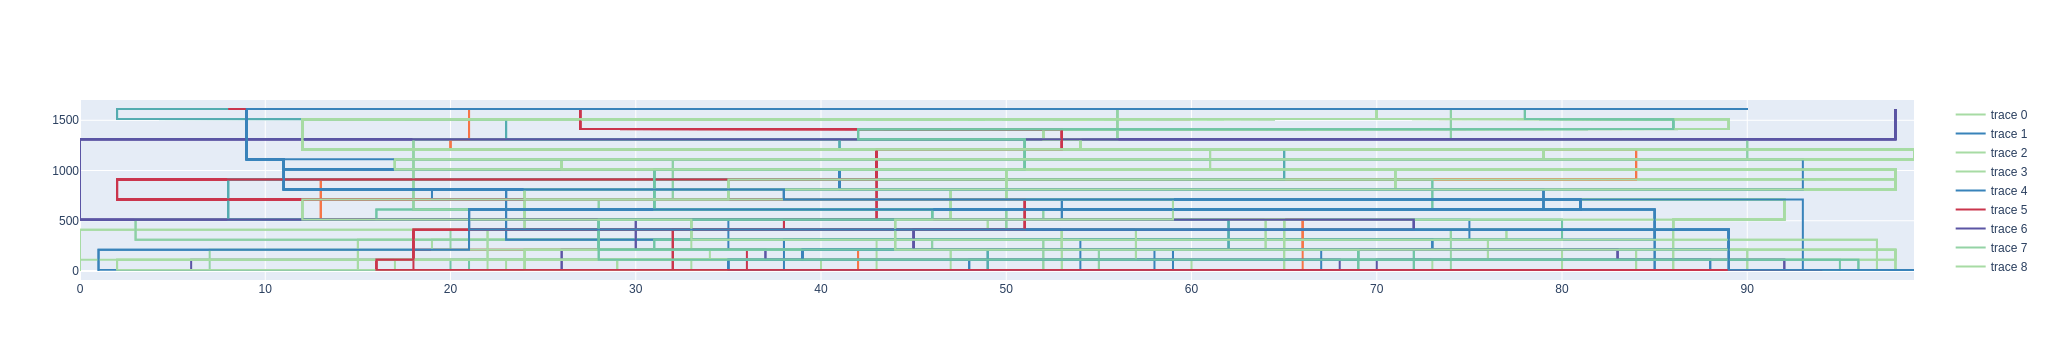

In [87]:
fig